```
┌─────────────────────────────────────────┐
│  STEP 1 · Load & Explore Data           │
│  df.shape · df.head() · df.info()       │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 2 · Create Target Column          │
│  G3 >= 10 → Pass  |  G3 < 10 → Fail    │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 3 · EDA & Visualization           │
│  distributions · heatmap · plots        │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 4 · Preprocessing                 │
│  LabelEncoder · StandardScaler · split  │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 5 · Build Pipeline + KNN          │
│  Pipeline → KNeighborsClassifier        │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 6 · Evaluate & Tune K             │
│  accuracy · confusion matrix · report   │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 7 · Save Model                    │
│  joblib · pickle the pipeline           │
└──────────────────┬──────────────────────┘
                   │
                   ▼
┌─────────────────────────────────────────┐
│  STEP 8 · Streamlit App + Deploy        │
│  Streamlit Cloud · live public URL      │
└─────────────────────────────────────────┘
```

## Step 1 · Load & Explore Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("student_exam_data.csv")
display("Shape of the file" , df.shape)
display("DATASET",df.head())

'Shape of the file'

(1000, 3)

'DATASET'

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [5]:
print("Columns:", df.columns.tolist())
print("\nPass/Fail unique values:", df['Pass/Fail'].unique())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Columns: ['Study Hours', 'Previous Exam Score', 'Pass/Fail']

Pass/Fail unique values: [0 1]

Missing values:
 Study Hours            0
Previous Exam Score    0
Pass/Fail              0
dtype: int64

Data types:
 Study Hours            float64
Previous Exam Score    float64
Pass/Fail                int64
dtype: object


In [6]:
print("Total students:", len(df))
print("\nPass/Fail count:")
print(df['Pass/Fail'].value_counts())
print("\nPass rate:", round(df['Pass/Fail'].mean() * 100, 2), "%")
print("\nStats summary:")
df.describe()

Total students: 1000

Pass/Fail count:
Pass/Fail
0    632
1    368
Name: count, dtype: int64

Pass rate: 36.8 %

Stats summary:


,Study Hours,Previous Exam Score,Pass/Fail
count,1000.000000,1000.000000,1000.000000
mean,5.487055,68.917084,0.368000
std,2.686850,17.121032,0.482503
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


## ✅ Step 1 Complete — What we found
```
- 1000 students · 3 columns
- No missing values
- Target: Pass/Fail already encoded (0=Fail, 1=Pass)
- Pass rate: 36.8% → imbalanced dataset
- Features: Study Hours · Previous Exam Score
```

## Step 3 · EDA & Visualization

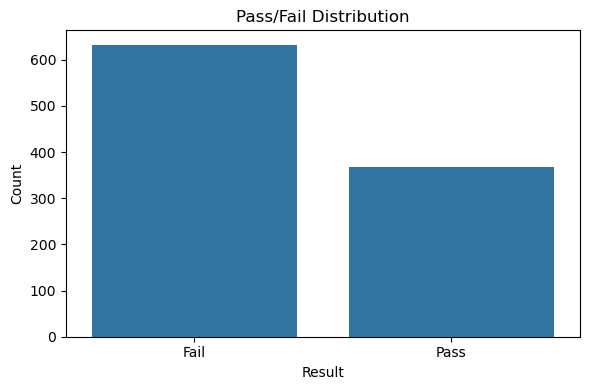

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pass/Fail",data=df)
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.title('Pass/Fail Distribution')
plt.xlabel('Result')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Axes: xlabel='Study Hours', ylabel='Count'>

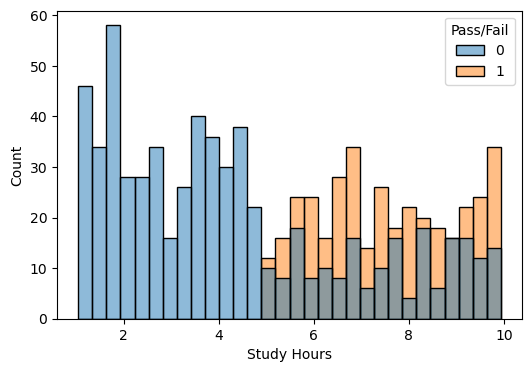

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(data=df,x="Study Hours" , bins = 30, hue = "Pass/Fail")

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# deviding the dataset
X = df[["Study Hours","Previous Exam Score"]]
y = df["Pass/Fail"]

In [11]:
# train and spliting the datasets

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
print("X train dataset size",X_train.shape)
print("X test dataset size",X_test.shape)
print("y train dataset size",y_train.shape)
print("y test dataset size",y_test.shape)

X train dataset size (800, 2)
X test dataset size (200, 2)
y train dataset size (800,)
y test dataset size (200,)


In [13]:
# oversampling using the SMOTE technique
# smote is only used in training data
smote = SMOTE(random_state=42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

In [14]:
# checking the imbalance data
y_train.value_counts()

Pass/Fail
0    498
1    302
Name: count, dtype: int64

In [15]:
y_train_res.value_counts()

Pass/Fail
0    498
1    498
Name: count, dtype: int64

In [16]:
X_train.value_counts()

Study Hours  Previous Exam Score
5.646703     96.062021              2
6.271980     68.324017              2
6.648023     44.508267              2
6.609683     98.801955              2
6.581193     81.681788              2
                                   ..
6.941776     60.009950              1
2.693090     75.413840              1
7.049220     57.026554              1
2.679131     56.612659              1
1.045554     55.278439              1
Name: count, Length: 485, dtype: int64

In [17]:
X_train_res.value_counts()

Study Hours  Previous Exam Score
7.938705     93.807305              4
6.506676     75.647843              4
6.690752     99.190915              4
9.233780     84.856563              4
6.867651     68.294571              4
                                   ..
6.560954     83.509200              1
6.542651     64.877447              1
6.535065     49.100493              1
6.529631     60.205508              1
6.518873     60.753030              1
Name: count, Length: 647, dtype: int64

In [18]:
# To choose best k Value 
for k in range(1,10):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_res, y_train_res)
    print(k, accuracy_score(y_test, model.predict(X_test)))

1 1.0
2 0.995
3 0.99
4 0.99
5 0.99
6 0.99
7 0.98
8 0.985
9 0.985


In [19]:
#model create

model = KNeighborsClassifier(n_neighbors=3)

# train model

model.fit(X_train_res,y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [20]:
# prdiction on test data
y_pred = model.predict(X_test)

In [21]:
# accuracy
acc = accuracy_score(y_test,y_pred)
print("Accuracy:", acc,"\n")
conf_mat = confusion_matrix(y_test,y_pred)
print("Confusion Metrics:\n", conf_mat,"\n\n")
cl_report = classification_report(y_test,y_pred)
print("Classification Report:", cl_report)

Accuracy: 0.99 

Confusion Metrics:
 [[133   1]
 [  1  65]] 


Classification Report:               precision    recall  f1-score   support

           0       0.99      0.99      0.99       134
           1       0.98      0.98      0.98        66

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [22]:
print(y_test.value_counts())

Pass/Fail
0    134
1     66
Name: count, dtype: int64


In [23]:
# load model

In [24]:
# to save the model we use this library
import joblib

joblib.dump(model, "knn_model.pkl")

['knn_model.pkl']